# Predicción de Ingresos Totales del Canal de Panamá
## Modelo: Árbol de Decisión

## ¿Qué es un Árbol de Decisión para Regresión?

Un **Árbol de Decisión** es un modelo de aprendizaje supervisado que particiona recursivamente el espacio de features en regiones rectangulares, asignando una predicción constante a cada región.

### ¿Cómo funciona?

1. **Partición recursiva**: El algoritmo divide el espacio de features evaluando todos los posibles puntos de corte en todas las variables. En cada nodo, selecciona la combinación feature-valor que **minimiza el error** en los subgrupos resultientes.

2. **Criterio de división (MSE)**: Para regresión, se utiliza el **Mean Squared Error (Error Cuadrático Medio)** como criterio de impureza:
   $$\text{MSE} = \frac{1}{n} \sum_{i=1}^{n} (y_i - \bar{y})^2$$
   El algoritmo busca el split que reduzca más el MSE promedio de los nodos hijos respecto al nodo padre.

3. **Pureza**: Un nodo es "puro" cuando todos sus samples tienen valores similares. El MSE mide la varianza dentro de cada nodo — a menor MSE, mayor pureza.

4. **Control de profundidad (`max_depth`)**: La profundidad máxima controla cuántas veces se puede dividir el árbol. Un árbol muy profundo captura ruido (overfitting); uno muy superficial no captura patrones complejos (underfitting).

5. **Predicción**: La predicción para una nueva observación es la **media de los valores objetivo** de todos los samples que caen en la hoja correspondiente.

### Ventajas

- **Intuitivo y interpretable**: Se puede visualizar como un diagrama de flujo de reglas de decisión.
- **Relaciones no lineales**: Captura patrones complejos sin asumir linealidad.
- **No requiere escalado de features**: A diferencia de modelos como SVM o regresión lineal, no necesita normalización.
- **Maneja datos mixtos**: Funciona con variables numéricas y categóricas.

### Limitaciones

- **Tendencia al overfitting**: Sin control de profundidad, puede memorizar el ruido de los datos.
- **Inestabilidad**: Pequeños cambios en los datos pueden generar un árbol completamente diferente.
- **Solo divisiones ortogonales**: Los splits son paralelos a los ejes, lo que dificulta modelar relaciones diagonales.
- **Predicciones escalonadas**: La salida es constante dentro de cada hoja, generando discontinuidades.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

Matplotlib is building the font cache; this may take a moment.


## 1. Carga y Preparación de Datos

In [2]:
df = pd.read_csv("A07607236202602121443442025_transporte_acp.csv", encoding='latin-1')

df = df.rename(columns={
    "Ingresos por Peaje Panamax": "Ingresos Panamax",
    "Ingresos por Peaje NeoPanamax": "Ingresos NeoPanamax",
    "Tonelada Netas Neopanamax": "Toneladas Netas NeoPanamax"
})

df["Ingresos Totales"] = df["Ingresos Panamax"] + df["Ingresos NeoPanamax"]
df["Total Transitos"] = (
    df["Transito de Naves Alto Calado Panamax"]
    + df["Transito de Naves Pequeño Calado Panamax"]
    + df["Transito de Naves NeoPanamax"]
)
df["Total Toneladas"] = df["Toneladas Netas Panamax"] + df["Toneladas Netas NeoPanamax"]
df["Total Volumen"] = df["Volumen de Carga Panamax"] + df["Volumen de Carga NeoPanamax"]

meses = {
    "Enero": 1, "Febrero": 2, "Marzo": 3, "Abril": 4,
    "Mayo": 5, "Junio": 6, "Julio": 7, "Agosto": 8,
    "Septiembre": 9, "Octubre": 10, "Noviembre": 11, "Diciembre": 12
}
df["Num_Mes"] = df["Mes"].map(meses)
df["Mes_Indice"] = range(len(df))

print(f"Dimensiones del dataset: {df.shape}")
df.head()

Dimensiones del dataset: (72, 17)


,Año,Mes,Transito de Naves Alto Calado Panamax,Transito de Naves Pequeño Calado Panamax,Ingresos Panamax,Toneladas Netas Panamax,Volumen de Carga Panamax,Transito de Naves NeoPanamax,Ingresos NeoPanamax,Toneladas Netas NeoPanamax,Volumen de Carga NeoPanamax,Ingresos Totales,Total Transitos,Total Toneladas,Total Volumen,Num_Mes,Mes_Indice
0,2020,Enero,826,149,110198056,21167387,13324583,308,135551279,23811798,9311252,245749335,1283,44979185,22635835,1,0
1,2020,Febrero,753,206,100158695,19293825,13054336,268,112186169,19811487,8662008,212344864,1227,39105312,21716344,2,1
2,2020,Marzo,825,124,110757041,21512145,15397768,261,105134233,19232310,7836721,215891274,1210,40744455,23234489,3,2
3,2020,Abril,698,53,96144271,17615626,13232901,271,121704852,19898460,9636220,217849123,1022,37514086,22869121,4,3
4,2020,Mayo,640,43,85960793,15530225,12631808,254,115570390,18800359,7521629,201531183,937,34330584,20153437,5,4


## 2. Selección de Features y División de Datos

In [3]:
features = [
    "Transito de Naves Alto Calado Panamax",
    "Transito de Naves Pequeño Calado Panamax",
    "Toneladas Netas Panamax",
    "Volumen de Carga Panamax",
    "Transito de Naves NeoPanamax",
    "Toneladas Netas NeoPanamax",
    "Volumen de Carga NeoPanamax",
    "Total Transitos",
    "Total Toneladas",
    "Total Volumen",
    "Num_Mes",
    "Mes_Indice"
]

target = "Ingresos Totales"

train = df[df["Año"] < 2025]
val = df[df["Año"] == 2025]

X_train = train[features]
y_train = train[target]
X_val = val[features]
y_val = val[target]

print(f"Datos de entrenamiento: {X_train.shape[0]} registros (2020-2024)")
print(f"Datos de validación:    {X_val.shape[0]} registros (2025)")

Datos de entrenamiento: 60 registros (2020-2024)
Datos de validación:    12 registros (2025)


## 3. Búsqueda del Mejor hiperparámetro (Profundidad del Árbol)

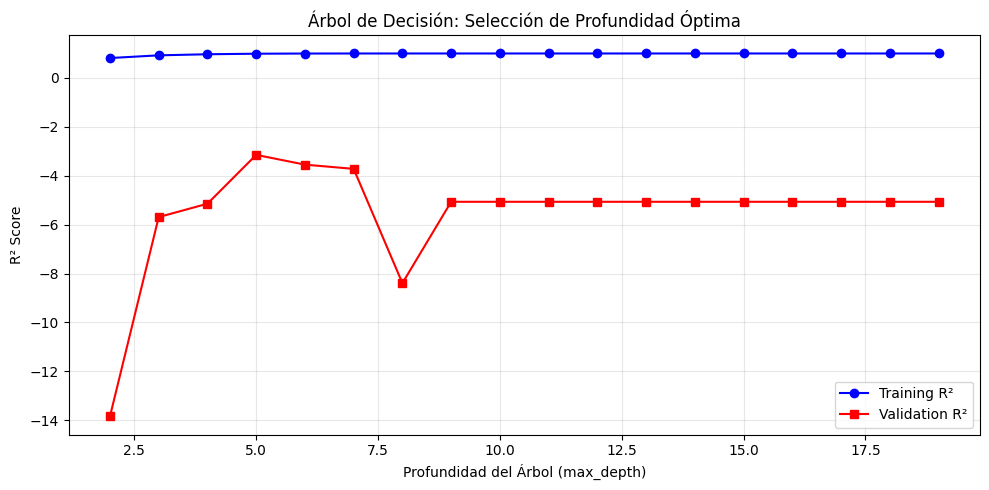

Profundidad óptima (mayor R² en validación): 5


In [4]:
depths = range(2, 20)
train_scores = []
val_scores = []

for d in depths:
    tree = DecisionTreeRegressor(max_depth=d, random_state=42)
    tree.fit(X_train, y_train)
    train_scores.append(tree.score(X_train, y_train))
    val_scores.append(tree.score(X_val, y_val))

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(list(depths), train_scores, 'b-o', label='Training R²')
ax.plot(list(depths), val_scores, 'r-s', label='Validation R²')
ax.set_xlabel('Profundidad del Árbol (max_depth)')
ax.set_ylabel('R² Score')
ax.set_title('Árbol de Decisión: Selección de Profundidad Óptima')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

best_depth = list(depths)[np.argmax(val_scores)]
print(f"Profundidad óptima (mayor R² en validación): {best_depth}")

## 4. Entrenamiento del Modelo

In [5]:
model = DecisionTreeRegressor(max_depth=best_depth, random_state=42)
model.fit(X_train, y_train)
y_pred_val = model.predict(X_val)

print(f"Profundidad del árbol: {model.get_depth()}")
print(f"Número de hojas: {model.get_n_leaves()}")

Profundidad del árbol: 5
Número de hojas: 27


## 5. Visualización del Árbol

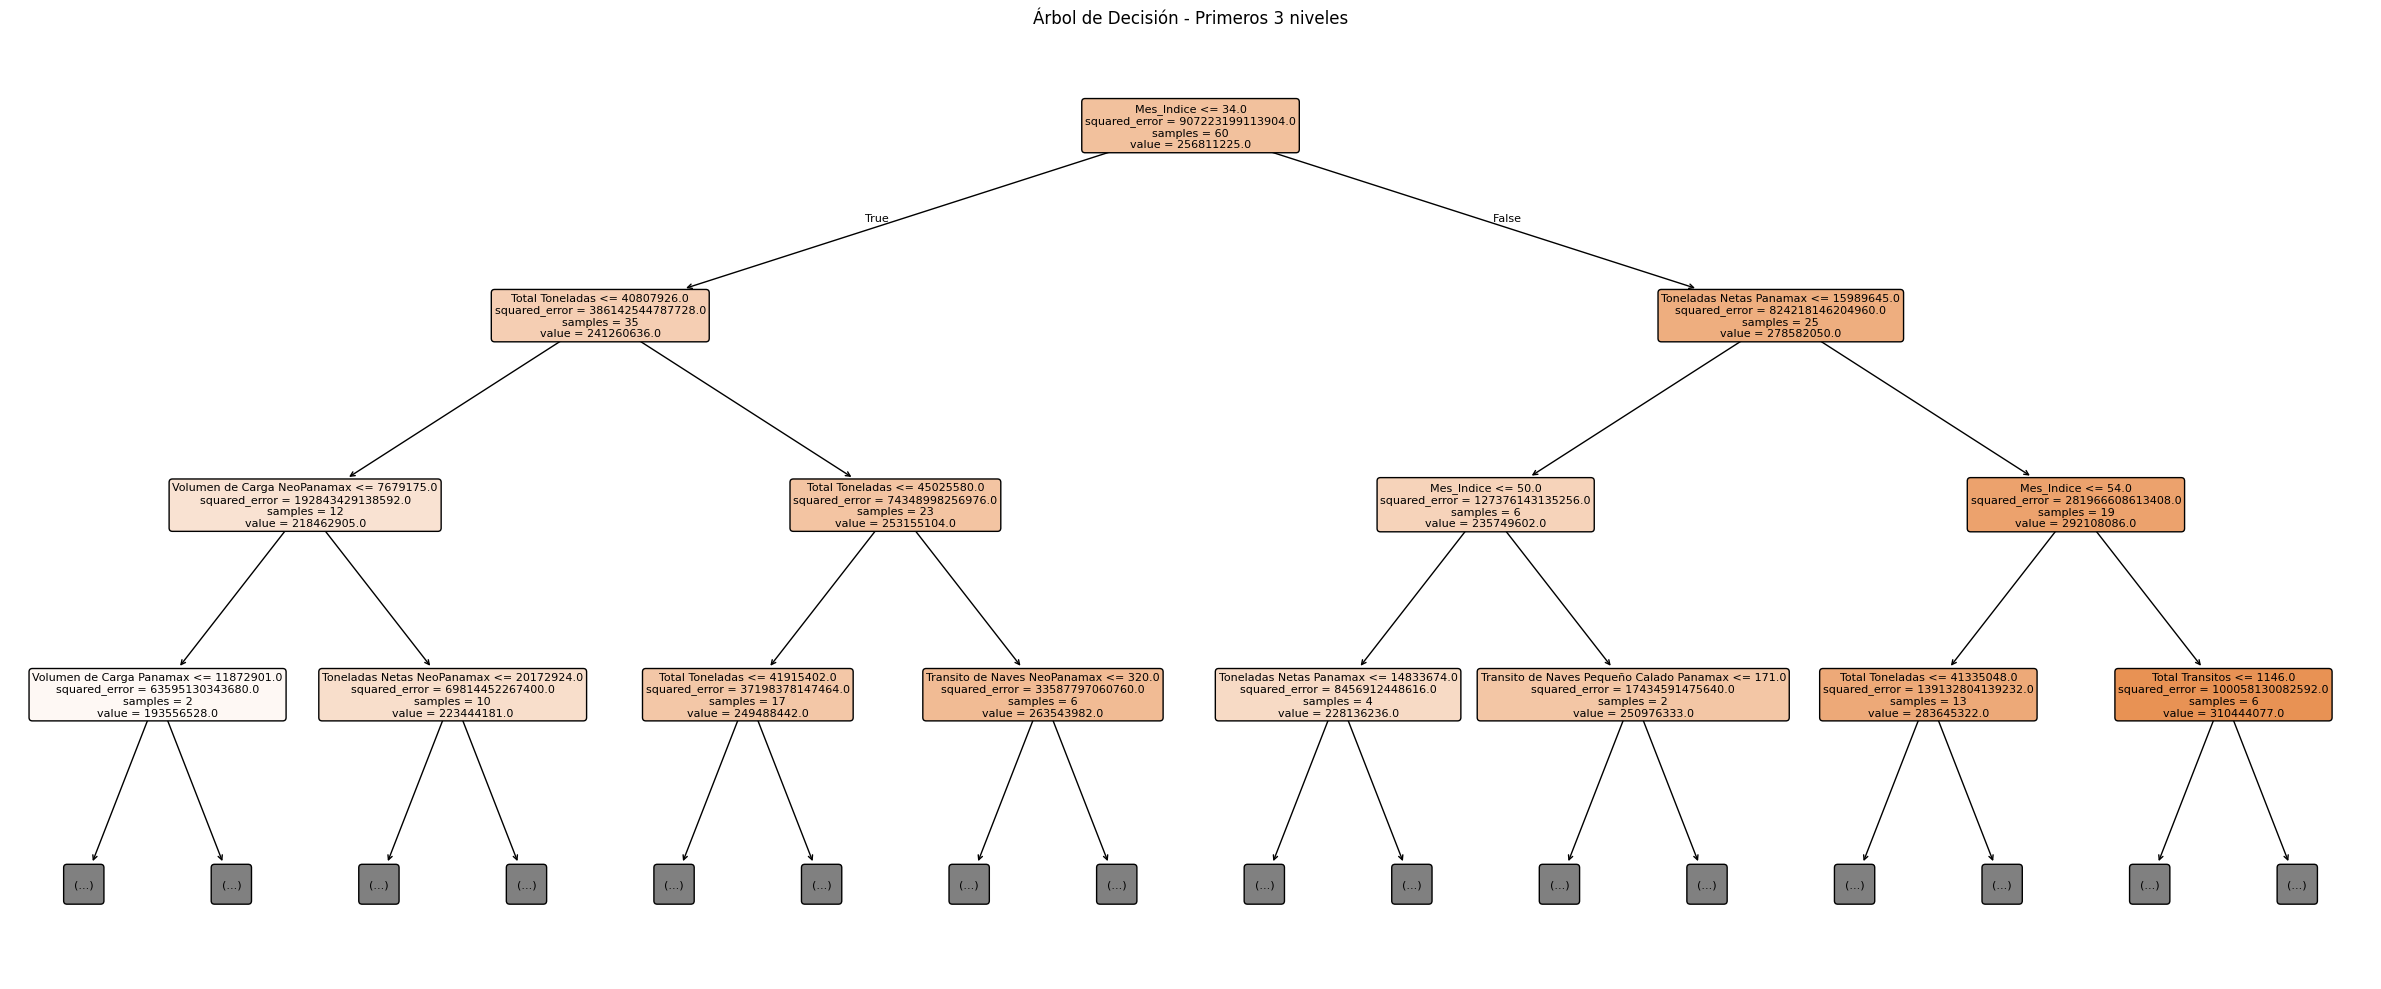

In [6]:
fig, ax = plt.subplots(figsize=(24, 10))
plot_tree(model, feature_names=features, filled=True, rounded=True, 
          ax=ax, fontsize=8, max_depth=3, precision=0)
plt.title('Árbol de Decisión - Primeros 3 niveles')
plt.tight_layout()
plt.show()

## 6. Evaluación del Modelo

In [7]:
rmse = np.sqrt(mean_squared_error(y_val, y_pred_val))
mae = mean_absolute_error(y_val, y_pred_val)
r2 = r2_score(y_val, y_pred_val)

print(f"=== Métricas de Evaluación (Validación 2025) ===")
print(f"RMSE:  ${rmse:,.0f}")
print(f"MAE:   ${mae:,.0f}")
print(f"R²:    {r2:.4f}")

=== Métricas de Evaluación (Validación 2025) ===
RMSE:  $27,963,631
MAE:   $25,917,339
R²:    -3.1468


## 7. Visualización: Reales vs Predichos (2025)

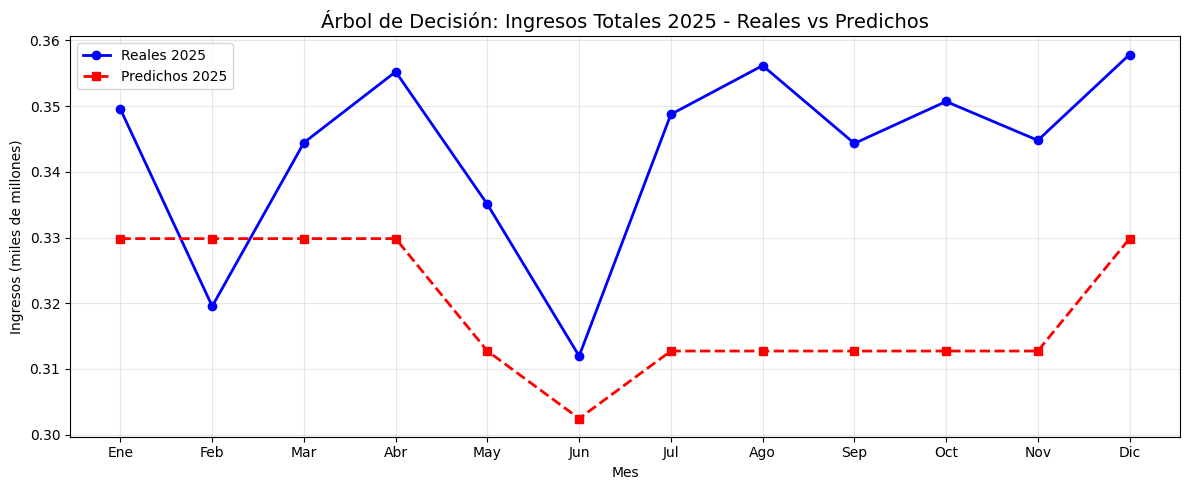

In [8]:
fig, ax = plt.subplots(figsize=(12, 5))
x_axis = range(1, 13)
meses_labels = ["Ene", "Feb", "Mar", "Abr", "May", "Jun", "Jul", "Ago", "Sep", "Oct", "Nov", "Dic"]

ax.plot(x_axis, y_val.values / 1e9, 'b-o', label='Reales 2025', linewidth=2)
ax.plot(x_axis, y_pred_val / 1e9, 'r--s', label='Predichos 2025', linewidth=2)
ax.set_xticks(x_axis)
ax.set_xticklabels(meses_labels)
ax.set_title('Árbol de Decisión: Ingresos Totales 2025 - Reales vs Predichos', fontsize=14)
ax.set_xlabel('Mes')
ax.set_ylabel('Ingresos (miles de millones)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 8. Importancia de Features

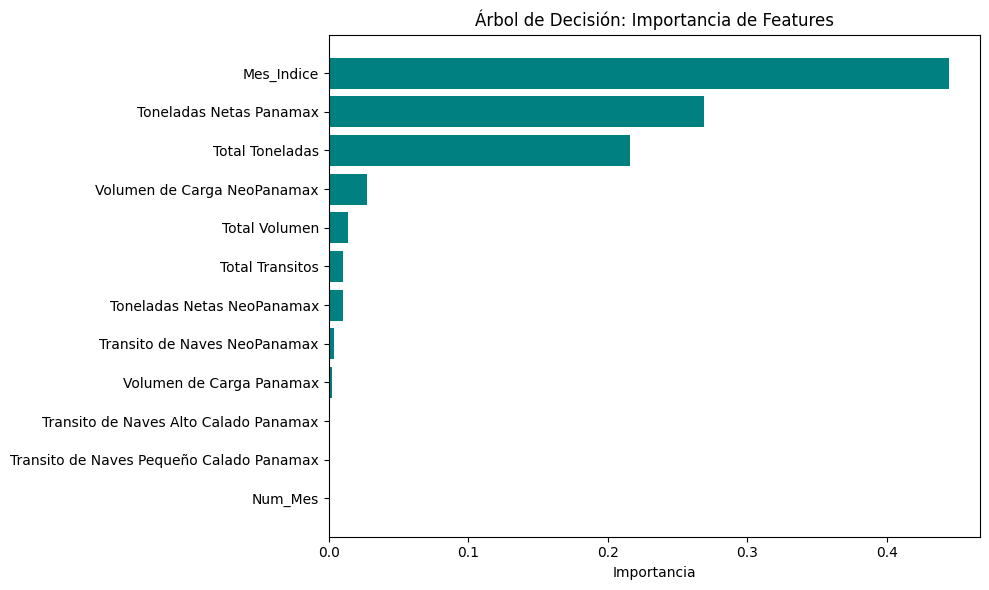

In [9]:
importance = pd.DataFrame({
    "Feature": features,
    "Importancia": model.feature_importances_
}).sort_values("Importancia", ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(importance["Feature"], importance["Importancia"], color='teal')
ax.set_xlabel('Importancia')
ax.set_title('Árbol de Decisión: Importancia de Features')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## 9. Predicción de Ingresos Totales 2026

In [10]:
meses_nombre = ["Enero", "Febrero", "Marzo", "Abril", "Mayo", "Junio",
                "Julio", "Agosto", "Septiembre", "Octubre", "Noviembre", "Diciembre"]

predict_2026 = pd.DataFrame()
for i, mes in enumerate(meses_nombre):
    row = {
        "Año": 2026,
        "Mes": mes,
        "Num_Mes": i + 1,
        "Mes_Indice": 72 + i,
    }
    month_avg = df[df["Mes"] == mes][features[:-2]].mean()
    for feat in features[:-2]:
        row[feat] = month_avg[feat]
    predict_2026 = pd.concat([predict_2026, pd.DataFrame([row])], ignore_index=True)

X_2026 = predict_2026[features]
predicciones_2026 = model.predict(X_2026)
predict_2026["Ingresos Totales Predichos"] = predicciones_2026

print("=== Predicción de Ingresos Totales 2026 ===")
for _, row in predict_2026.iterrows():
    print(f"{row['Mes']:12s}: ${row['Ingresos Totales Predichos']:>18,.0f}")

total_2026 = predict_2026["Ingresos Totales Predichos"].sum()
print(f"\n{'Total 2026':12s}: ${total_2026:>18,.0f}")

=== Predicción de Ingresos Totales 2026 ===
Enero       : $       329,842,491
Febrero     : $       302,455,128
Marzo       : $       329,842,491
Abril       : $       302,455,128
Mayo        : $       302,455,128
Junio       : $       302,455,128
Julio       : $       312,728,293
Agosto      : $       312,728,293
Septiembre  : $       302,455,128
Octubre     : $       312,728,293
Noviembre   : $       312,728,293
Diciembre   : $       329,842,491

Total 2026  : $     3,752,716,285


## 10. Visualización de Tendencia Histórica y Predicción 2026

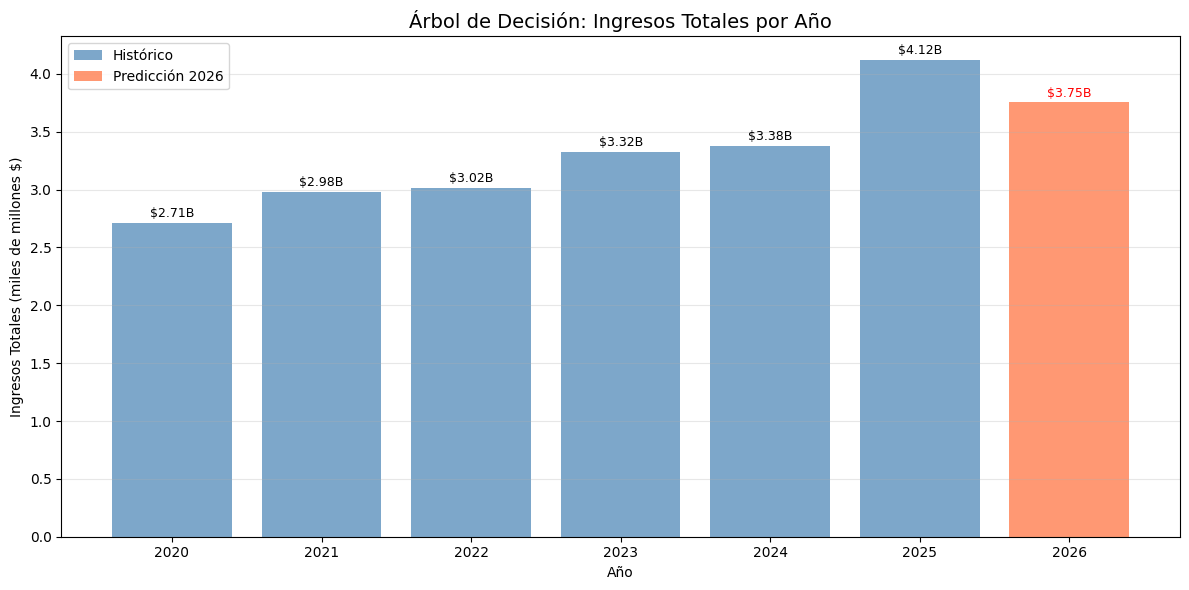

In [11]:
ingresos_anuales = df.groupby("Año")["Ingresos Totales"].sum()

fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(ingresos_anuales.index.astype(str), ingresos_anuales.values / 1e9, 
       color='steelblue', alpha=0.7, label='Histórico')
ax.bar("2026", total_2026 / 1e9, color='coral', alpha=0.8, label='Predicción 2026')

for i, (year, val) in enumerate(ingresos_anuales.items()):
    ax.text(i, val / 1e9 + 0.05, f'${val/1e9:.2f}B', ha='center', fontsize=9)
ax.text(len(ingresos_anuales), total_2026 / 1e9 + 0.05, f'${total_2026/1e9:.2f}B', 
        ha='center', fontsize=9, color='red')

ax.set_title('Árbol de Decisión: Ingresos Totales por Año', fontsize=14)
ax.set_xlabel('Año')
ax.set_ylabel('Ingresos Totales (miles de millones $)')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [12]:
predict_2026[["Año", "Mes", "Ingresos Totales Predichos"]].to_csv("prediccion_2026.csv", index=False)
print("Predicciones exportadas a prediccion_2026.csv")

Predicciones exportadas a prediccion_2026.csv


## Conclusiones
- El Árbol de Decisión particiona el espacio de features en regiones rectangulares para predecir ingresos.
- La profundidad del árbol controla el balance entre sesgo y varianza (overfitting).
- Permite visualizar fácilmente las reglas de decisión y la importancia de cada feature.
- Limitaciones: puede sobreajustar, las predicciones son escalones, sensible a cambios pequeños en datos.